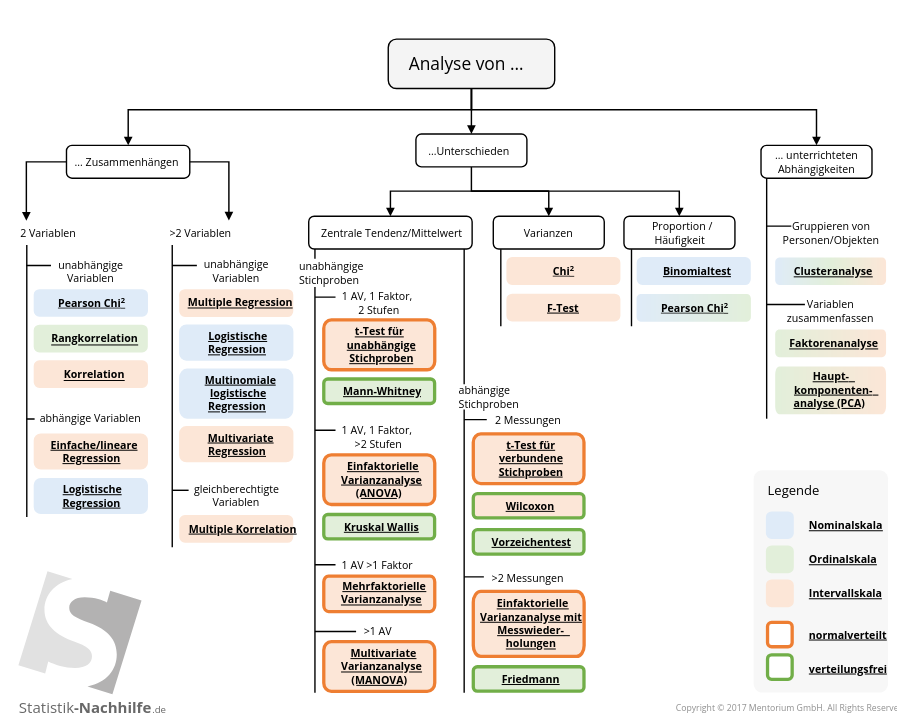

In [6]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt


In [23]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from IPython.display import display

np.random.seed(42)
n = 500

# 1. NON-NORMAL (SKEWED) INTERVAL VARIABLE: VO2_Max
# Gamma distribution creates a long tail (right-skewed)
# Most runners cluster around 40-50, but elites go up to 80+
vo2_max = np.random.gamma(shape=12, scale=4, size=n)

# 2. CORRELATING THE NOMINAL OUTCOME: Medal_Won
# Probability of winning is a function of VO2_Max
# We use a Sigmoid function: P(Medal) = 1 / (1 + e^-(k * (x - x0)))
k = 0.2  # Steeper curve
x0 = 55  # The "tipping point" VO2 Max for winning
prob_winning = 1 / (1 + np.exp(-k * (vo2_max - x0)))
medal_won = np.random.binomial(1, prob_winning)

# 3. OTHER VARIABLES
data = {
    'Runner_ID': range(n),
    'Heart_Rate': np.random.normal(165, 12, n),
    'VO2_Max': vo2_max,
    'Experience': np.random.choice([1, 2, 3], n, p=[0.5, 0.3, 0.2]), # 1: Amateur, 2: Int, 3: Pro
    'Medal_Won': medal_won,
    'Gender': np.random.choice(['M', 'F'], n),
    'Recovery_Pre': np.random.normal(70, 10, n),
    'Recovery_Post': np.random.normal(75, 10, n),
    'Group': np.random.choice(['A', 'B', 'C'], n)
}

df = pd.DataFrame(data)

display(df.head())
display(df.tail())

,Runner_ID,Heart_Rate,VO2_Max,Experience,Medal_Won,Gender,Recovery_Pre,Recovery_Post,Group
0,0,185.070869,53.787356,3,0,F,59.706285,69.687857,A
1,1,170.028228,44.802991,1,0,M,56.473297,79.838767,C
2,2,156.539858,43.540069,2,0,M,54.776408,63.977079,B
3,3,164.330771,43.540284,2,1,F,81.126884,81.813595,B
4,4,171.699923,71.738861,2,1,F,63.707366,79.086073,A


,Runner_ID,Heart_Rate,VO2_Max,Experience,Medal_Won,Gender,Recovery_Pre,Recovery_Post,Group
495,495,173.134504,39.295059,3,0,M,64.868036,73.343686,A
496,496,157.151092,39.521160,2,0,M,62.820811,75.785770,C
497,497,143.032405,55.859296,1,0,F,67.694754,53.712659,A
498,498,171.134431,71.163381,1,0,F,81.797252,79.581681,B
499,499,181.483903,75.754482,1,1,M,71.941076,65.202788,B


/tmp/ipykernel_6223/181589986.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0, 1], data=df, x='Medal_Won', y='Heart_Rate', palette='Set2', showfliers=False)


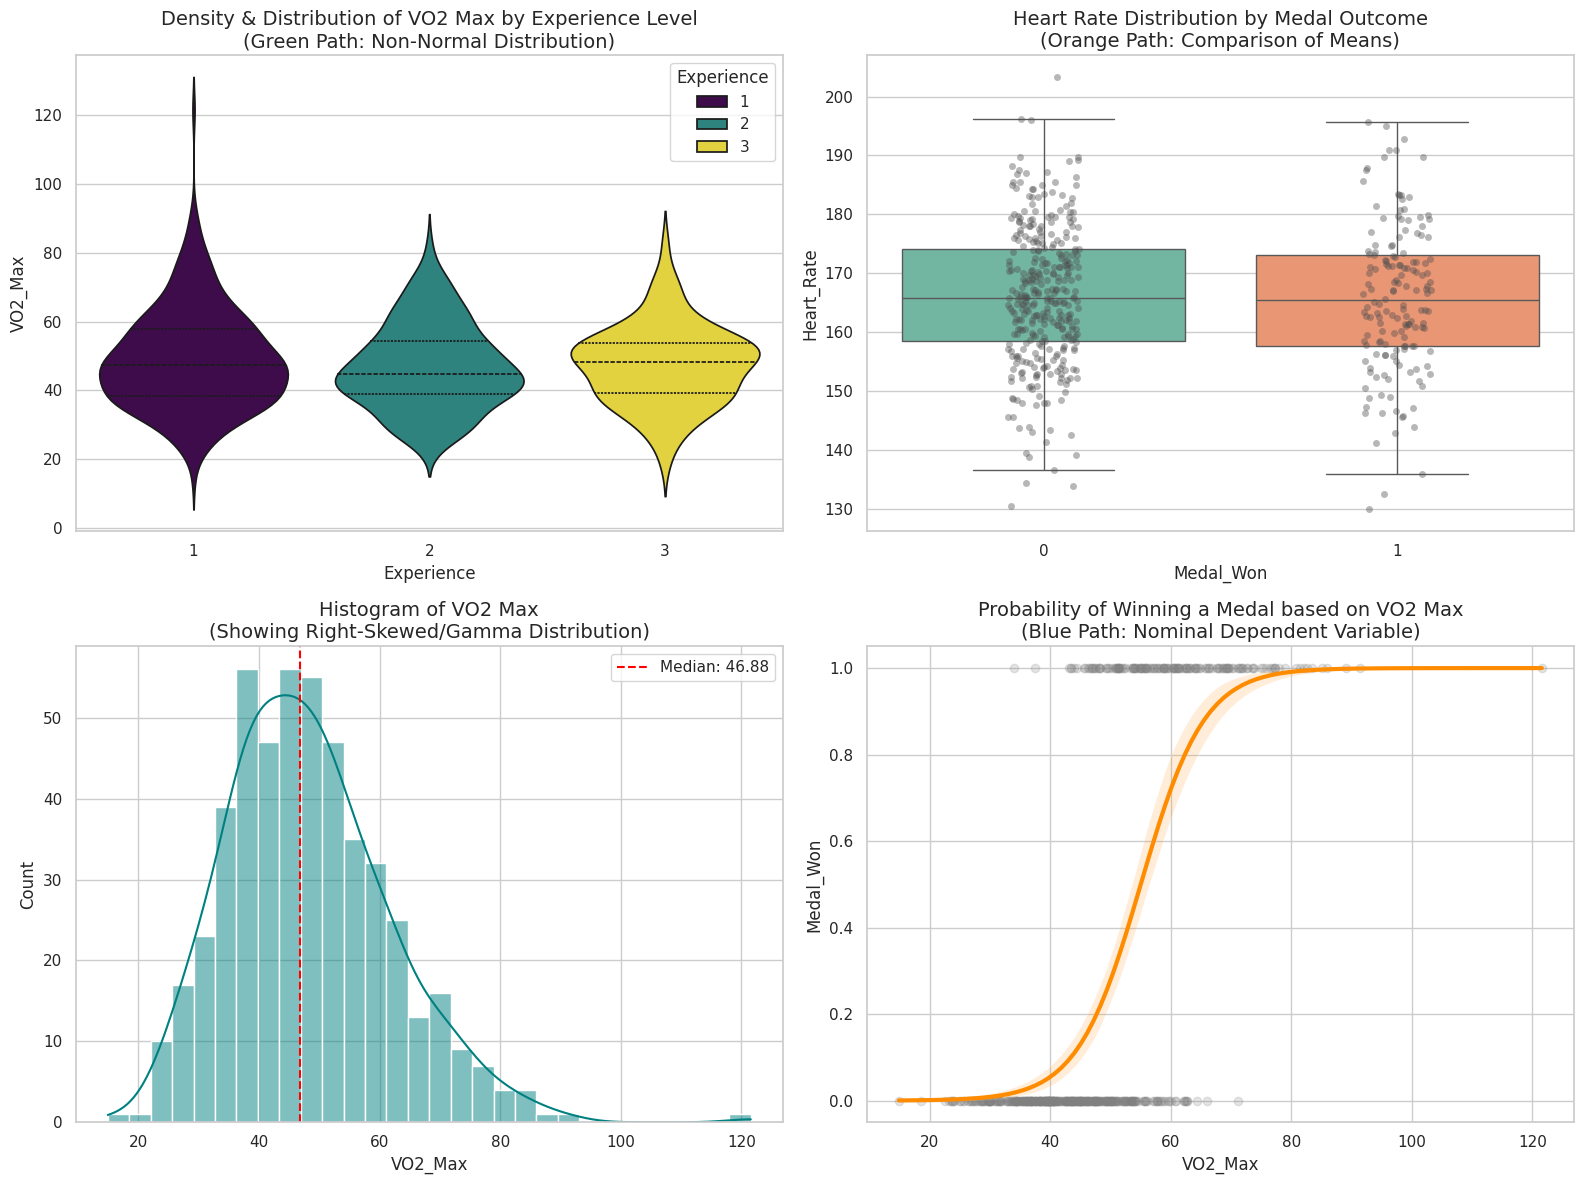

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- A. VIOLIN PLOT: VO2 Max by Experience ---
# Matches: "Analyse von Unterschieden" -> "Zentrale Tendenz"
sns.violinplot(ax=axes[0, 0], data=df, x='Experience', y='VO2_Max', hue='Experience', palette='viridis', inner="quart")
axes[0, 0].set_title("Density & Distribution of VO2 Max by Experience Level\n(Green Path: Non-Normal Distribution)", fontsize=14)

# --- B. SWARM PLOT: Medal Wins vs Heart Rate ---
# Matches: "Analyse von Unterschieden" -> "unabhängige Stichproben"
sns.boxplot(ax=axes[0, 1], data=df, x='Medal_Won', y='Heart_Rate', palette='Set2', showfliers=False)
sns.stripplot(ax=axes[0, 1], data=df, x='Medal_Won', y='Heart_Rate', color=".3", alpha=0.4)
axes[0, 1].set_title("Heart Rate Distribution by Medal Outcome\n(Orange Path: Comparison of Means)", fontsize=14)

# --- C. HISTOGRAM: VO2 Max Skewness ---
# Matches: "Legende" -> "verteilungsfrei" (Green)
sns.histplot(ax=axes[1, 0], data=df, x='VO2_Max', kde=True, color='teal', bins=30)
axes[1, 0].set_title("Histogram of VO2 Max\n(Showing Right-Skewed/Gamma Distribution)", fontsize=14)
axes[1, 0].axvline(df['VO2_Max'].median(), color='red', linestyle='--', label=f'Median: {df["VO2_Max"].median():.2f}')
axes[1, 0].legend()

# --- D. LOGISTIC REGRESSION CURVE ---
# Matches: "Analyse von Zusammenhängen" -> "Logistische Regression" (Blue)
sns.regplot(ax=axes[1, 1], data=df, x='VO2_Max', y='Medal_Won', logistic=True,
            scatter_kws={'alpha':0.2, 'color':'gray'}, line_kws={'color':'darkorange', 'linewidth': 3})
axes[1, 1].set_title("Probability of Winning a Medal based on VO2 Max\n(Blue Path: Nominal Dependent Variable)", fontsize=14)

plt.tight_layout()
plt.show()

# Relationships

When we want to see if two variables move together, we look at correlation and regression.

Pearson Correlation ($r$):
  - Measures the linear strength between two interval variables (e.g., Oxygen Intake vs. Running Speed).$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
  
  Simple Linear Regression:
  - Predicts a dependent variable ($y$) based on an independent variable ($x$).$$y = \beta_0 + \beta_1x + \epsilon$$


## Examples:

Pearson $Chi^2$:

  - Used here to see if Gender (Nominal) is related to winning a Medal (Nominal).

Korrelation:
  - Used Pearson for the continuous Heart_Rate and VO2_Max.

Rangkorrelation:
  - Used Spearman for Experience (Ordinal) vs Performance.

Lineare Regression:
  - Used to predict VO2_Max based on Heart_Rate.




In [24]:

# --- SECTION 1: ANALYSE VON ZUSAMMENHÄNGEN (Relationships) ---
print("--- 1. ANALYSIS OF RELATIONSHIPS ---")

# A. 2 Variables (Independent) - Pearson Chi2
contingency = pd.crosstab(df['Gender'], df['Medal_Won'])
chi2, p, _, _ = stats.chi2_contingency(contingency)
print(f"Pearson Chi2 (Gender vs Medal): p={p:.4f}")

# B. 2 Variables (Independent) - Correlation (Pearson & Spearman/Rank)
pearson_r, _ = stats.pearsonr(df['Heart_Rate'], df['VO2_Max'])
spearman_r, _ = stats.spearmanr(df['Experience'], df['VO2_Max'])
print(f"Pearson Correlation: {pearson_r:.4f}")
print(f"Rank Correlation (Spearman): {spearman_r:.4f}")

# C. 2 Variables (Dependent) - Linear Regression
X = sm.add_constant(df['Heart_Rate'])
model = sm.OLS(df['VO2_Max'], X).fit()
print(f"Linear Regression R-squared: {model.rsquared:.4f}")


--- 1. ANALYSIS OF RELATIONSHIPS ---
Pearson Chi2 (Gender vs Medal): p=0.9472
Pearson Correlation: 0.0319
Rank Correlation (Spearman): -0.0396
Linear Regression R-squared: 0.0010


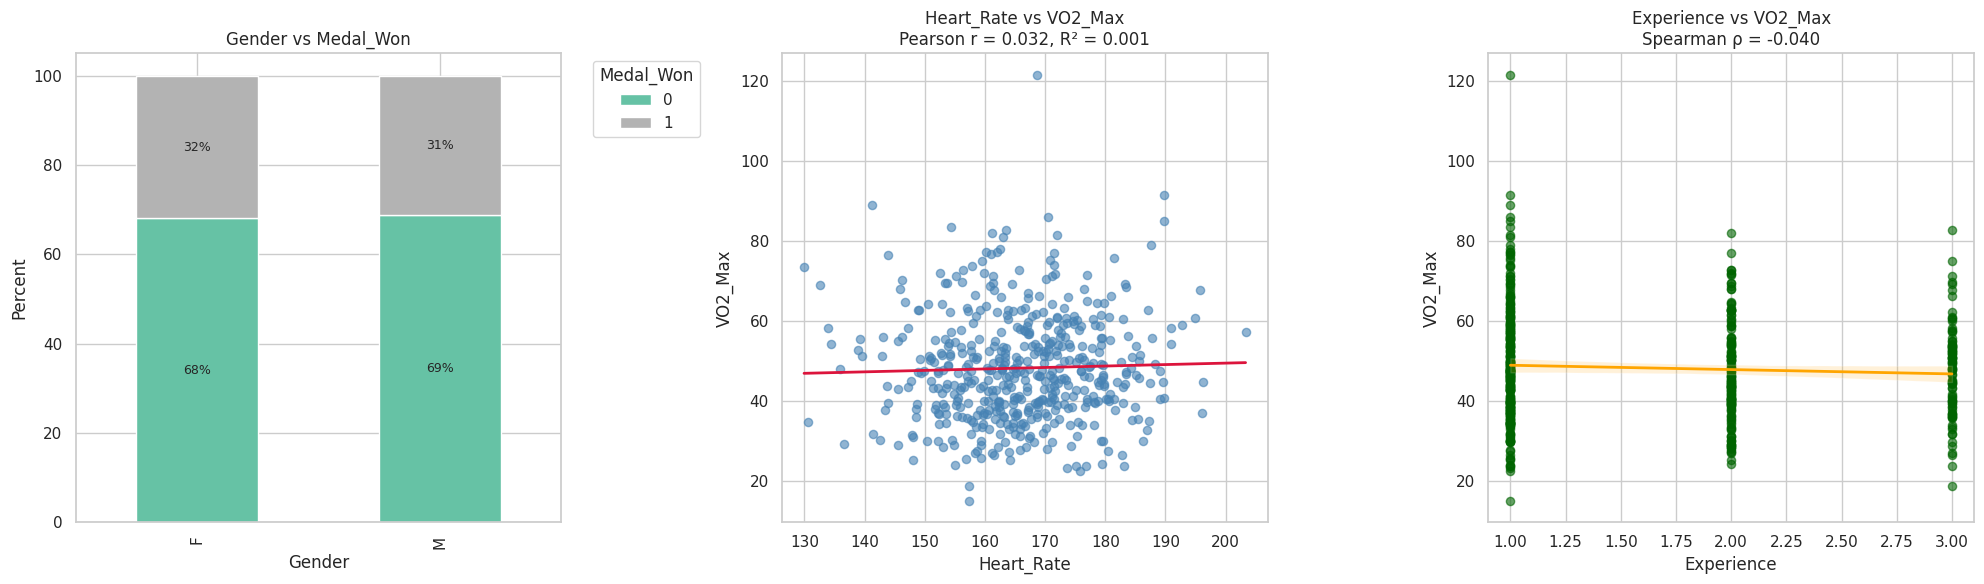

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set(style="whitegrid")

# -----------------------------
# 1) Gender vs Medal_Won
# -----------------------------
ct = pd.crosstab(df["Gender"], df["Medal_Won"], normalize="index") * 100

# Ensure consistent order if needed
ct = ct.sort_index()

# -----------------------------
# 2) Heart_Rate vs VO2_Max
# -----------------------------
pearson_r, pearson_p = stats.pearsonr(df["Heart_Rate"].dropna(), df["VO2_Max"].dropna())

# Fit regression line
temp = df[["Heart_Rate", "VO2_Max"]].dropna()
X = sm.add_constant(temp["Heart_Rate"])
model = sm.OLS(temp["VO2_Max"], X).fit()

# -----------------------------
# 3) Experience vs VO2_Max
# -----------------------------
spearman_r, spearman_p = stats.spearmanr(df["Experience"], df["VO2_Max"], nan_policy="omit")

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# A. 100% stacked bar chart
ct.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("Gender vs Medal_Won")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Percent")
axes[0].legend(title="Medal_Won", bbox_to_anchor=(1.05, 1), loc="upper left")

# Add percent labels inside bars
for i, (idx, row) in enumerate(ct.iterrows()):
    cum = 0
    for j, val in enumerate(row):
        if val > 5:
            axes[0].text(i, cum + val / 2, f"{val:.0f}%", ha="center", va="center", fontsize=9)
        cum += val

# B. Scatter + regression line
axes[1].scatter(temp["Heart_Rate"], temp["VO2_Max"], alpha=0.6, s=35, color="steelblue")
xline = np.linspace(temp["Heart_Rate"].min(), temp["Heart_Rate"].max(), 100)
yline = model.params["const"] + model.params["Heart_Rate"] * xline
axes[1].plot(xline, yline, color="crimson", linewidth=2)
axes[1].set_title(f"Heart_Rate vs VO2_Max\nPearson r = {pearson_r:.3f}, R² = {model.rsquared:.3f}")
axes[1].set_xlabel("Heart_Rate")
axes[1].set_ylabel("VO2_Max")

# C. Experience vs VO2_Max
axes[2].scatter(df["Experience"], df["VO2_Max"], alpha=0.6, s=35, color="darkgreen")
sns.regplot(
    data=df,
    x="Experience",
    y="VO2_Max",
    scatter=False,
    ax=axes[2],
    color="orange",
    line_kws={"linewidth": 2}
)
axes[2].set_title(f"Experience vs VO2_Max\nSpearman ρ = {spearman_r:.3f}")
axes[2].set_xlabel("Experience")
axes[2].set_ylabel("VO2_Max")

plt.tight_layout()
plt.show()

# Differences:

Independent Samples (2 Groups)

- t-Test (Normal):
    
  Compares the means of two independent groups (e.g., Male vs. Female sprint times).$$t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}}$$
  
- Mann-Whitney U (Distribution-free):
    
  Ranks the data instead of using raw means.Dependent Samples (Repeated Measures)

- Paired t-Test:
  
  Used for "Before and After" scenarios (e.g., Recovery score before and after a massage).

- ANOVA
  
  When you have 1 independent variable with more than 2 levels (e.g., three different recovery diets: Keto, High-Carb, Vegan) and you want to see if the average Recovery_Score differs.

   
  The F-statistic compares the variance between groups to the variance within groups:$$F = \frac{\text{Between-group variance}}{\text{Within-group variance}} = \frac{\sum n_j (\bar{X}_j - \bar{X})^2 / (k - 1)}{\sum \sum (X_{ij} - \bar{X}_j)^2 / (N - k)}$$
  
## Examples:

t-Test (Independent): Compared Heart Rates between Men and Women.

Mann-Whitney: The "Distribution-free" (Verteilungsfrei) version of the t-test above.

ANOVA: Compared Heart Rates across three different training Groups (A, B, and C).

t-Test (Dependent): Compared the same runners Pre and Post treatment.

In [25]:

# --- SECTION 2: ANALYSE VON UNTERSCHIEDEN (Differences) ---
print("\n--- 2. ANALYSIS OF DIFFERENCES ---")

# A. Independent Samples (t-test vs Mann-Whitney)
group_m = df[df['Gender'] == 'M']['Heart_Rate']
group_f = df[df['Gender'] == 'F']['Heart_Rate']
t_stat, p_t = stats.ttest_ind(group_m, group_f) # Parametric
u_stat, p_u = stats.mannwhitneyu(group_m, group_f) # Non-parametric
print(f"t-Test (Independent): p={p_t:.4f} | Mann-Whitney: p={p_u:.4f}")

# B. One-Way ANOVA (1 AV, 1 Factor, >2 levels)
model_anova = ols('Heart_Rate ~ C(Group)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)
print(f"One-way ANOVA p-value: {anova_table['PR(>F)'][0]:.4f}")

# C. Dependent Samples (Pre vs Post Training)
t_dep, p_dep = stats.ttest_rel(df['Recovery_Pre'], df['Recovery_Post'])
wilcoxon_stat, p_wil = stats.wilcoxon(df['Recovery_Pre'], df['Recovery_Post'])
print(f"t-Test (Dependent): p={p_dep:.4f} | Wilcoxon: p={p_wil:.4f}")



--- 2. ANALYSIS OF DIFFERENCES ---
t-Test (Independent): p=0.0638 | Mann-Whitney: p=0.0666
One-way ANOVA p-value: 0.4072
t-Test (Dependent): p=0.0000 | Wilcoxon: p=0.0000


/tmp/ipykernel_6223/531768808.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"One-way ANOVA p-value: {anova_table['PR(>F)'][0]:.4f}")


/tmp/ipykernel_6223/2199231744.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Gender", y="Heart_Rate", ax=axes[0], palette="Set2")
/tmp/ipykernel_6223/2199231744.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Group", y="Heart_Rate", ax=axes[1], palette="Set3")


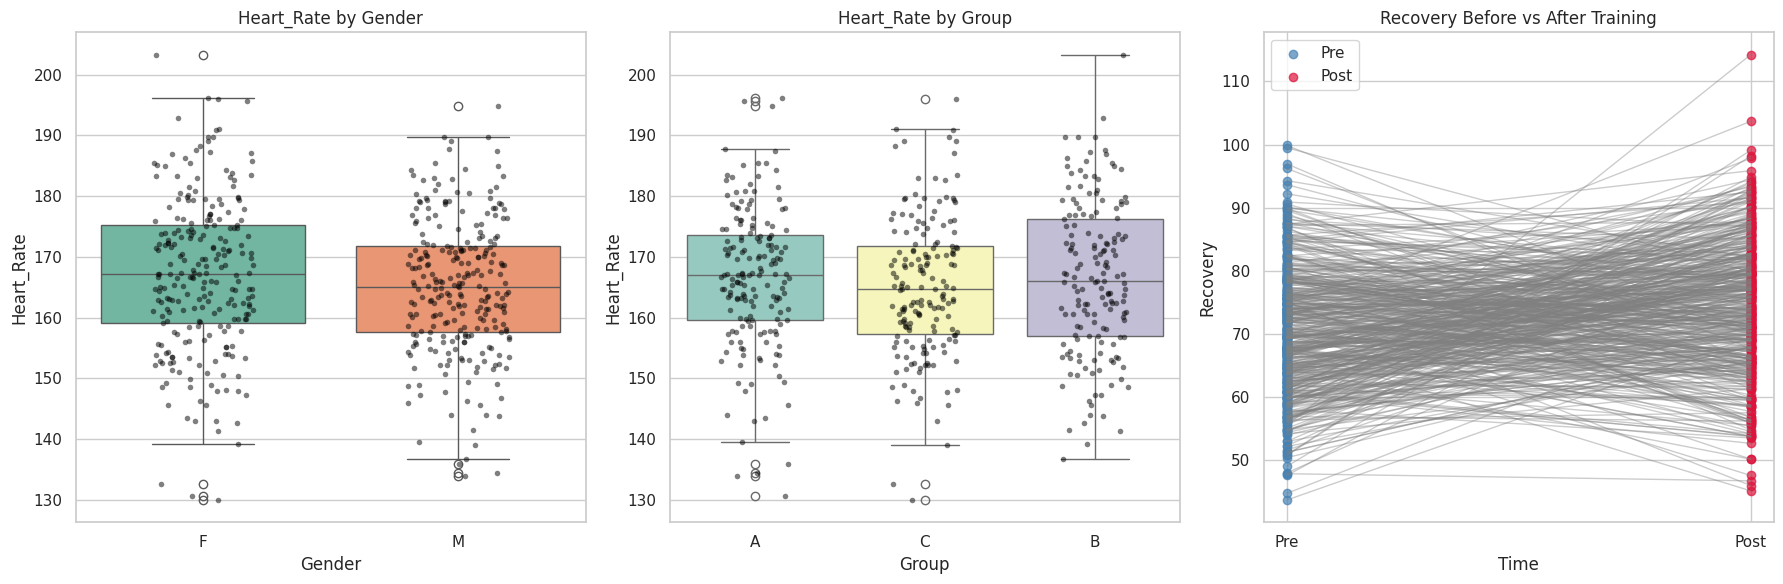

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1) Independent samples: Gender vs Heart_Rate
sns.boxplot(data=df, x="Gender", y="Heart_Rate", ax=axes[0], palette="Set2")
sns.stripplot(data=df, x="Gender", y="Heart_Rate", ax=axes[0],
              color="black", alpha=0.5, size=4, jitter=0.2)
axes[0].set_title("Heart_Rate by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Heart_Rate")

# 2) One-way ANOVA: Group vs Heart_Rate
sns.boxplot(data=df, x="Group", y="Heart_Rate", ax=axes[1], palette="Set3")
sns.stripplot(data=df, x="Group", y="Heart_Rate", ax=axes[1],
              color="black", alpha=0.5, size=4, jitter=0.2)
axes[1].set_title("Heart_Rate by Group")
axes[1].set_xlabel("Group")
axes[1].set_ylabel("Heart_Rate")

# 3) Paired samples: Recovery_Pre vs Recovery_Post
paired = df[["Recovery_Pre", "Recovery_Post"]].dropna().copy()
x_positions = [0, 1]

for _, row in paired.iterrows():
    axes[2].plot(x_positions, [row["Recovery_Pre"], row["Recovery_Post"]],
                 color="gray", alpha=0.4, linewidth=1)

axes[2].scatter(np.zeros(len(paired)), paired["Recovery_Pre"],
                color="steelblue", alpha=0.7, label="Pre")
axes[2].scatter(np.ones(len(paired)), paired["Recovery_Post"],
                color="crimson", alpha=0.7, label="Post")
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(["Pre", "Post"])
axes[2].set_title("Recovery Before vs After Training")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Recovery")
axes[2].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_6223/2455067354.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y='Heart_Rate', data=df, palette='Pastel1')


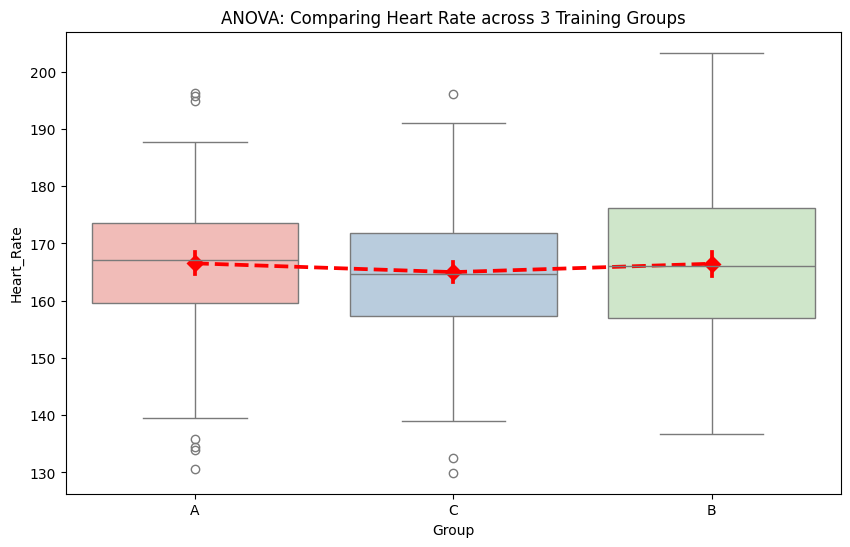

                sum_sq     df         F    PR(>F)
C(Group)    254.534430    2.0  0.900009  0.407228
Residual  70279.117195  497.0       NaN       NaN


In [26]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Model: Is Heart Rate affected by the Training Group (A, B, or C)?
model_anova = ols('Heart_Rate ~ C(Group)', data=df).fit()
anova_table = sm.stats.anova_lm(model_anova, typ=2)

# Visualization: Boxplot with Means
plt.figure(figsize=(10, 6))
sns.boxplot(x='Group', y='Heart_Rate', data=df, palette='Pastel1')
sns.pointplot(x='Group', y='Heart_Rate', data=df, color='red', markers='D', linestyles='--')
plt.title("ANOVA: Comparing Heart Rate across 3 Training Groups")
plt.show()

print(anova_table)

- Logistic Regression

  Used when the Dependent Variable is Nominal (binary).
  In our runner example:
  Can we predict if a runner wins a medal based on their VO2 Max?
  
  Instead of a straight line, we use the Sigmoid Function to map any value into a probability between 0 and 1:$$P(Y=1) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x)}}$$

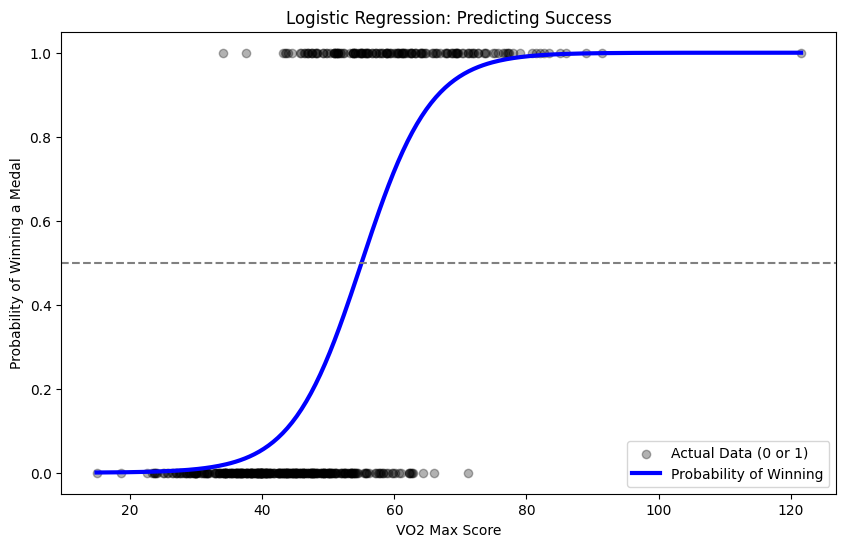

In [27]:
from sklearn.linear_model import LogisticRegression
from scipy.special import expit

# Data prep
X_log = df[['VO2_Max']].values
y_log = df['Medal_Won'].values

clf = LogisticRegression()
clf.fit(X_log, y_log)

# Visualization: The Sigmoid Curve
plt.figure(figsize=(10, 6))
X_test = np.linspace(df['VO2_Max'].min(), df['VO2_Max'].max(), 300)
loss = expit(X_test * clf.coef_ + clf.intercept_).ravel()

plt.scatter(df['VO2_Max'], df['Medal_Won'], color='black', alpha=0.3, label='Actual Data (0 or 1)')
plt.plot(X_test, loss, color='blue', linewidth=3, label='Probability of Winning')
plt.axhline(0.5, color='gray', linestyle='--')
plt.xlabel('VO2 Max Score')
plt.ylabel('Probability of Winning a Medal')
plt.title('Logistic Regression: Predicting Success')
plt.legend()
plt.show()

# Multiple Regression

We use this to see how multiple factors (Heart Rate + VO2 Max + Experience) simultaneously influence performance.

The Formula

$$Y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$$

Visualizing "Dependencies"

To see how all these variables interact a Heatmap is the best visual tool.

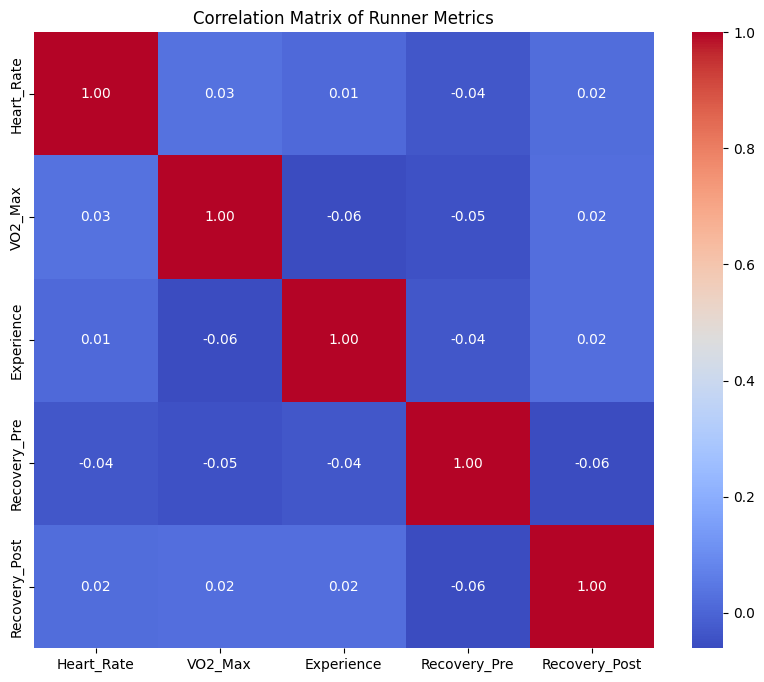

In [28]:
# Correlation Heatmap for all Interval variables
plt.figure(figsize=(10, 8))
correlation_matrix = df[['Heart_Rate', 'VO2_Max', 'Experience', 'Recovery_Pre', 'Recovery_Post']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Runner Metrics")
plt.show()

# Structure/Dependencies

- Clusteranalysis:
  
  (K-Means): Groups athletes into "types" (e.g., Power Athletes vs. Endurance Athletes) based on all their metrics combined. Grouped runners into "types" based on their physiological data.

- PCA (Principal Component Analysis):
  
  Finds a new axis (Principal Component) that captures the maximum variance in the data. This is used for "summarizing variables". Combined Heart_Rate and VO2_Max into a single "Fitness Index" to simplify the data.




--- 3. MULTIVARIATE & STRUCTURE ANALYSIS ---
PCA: Explained Variance Ratio: 0.5678
Cluster Analysis: Created 3 groups of runners.


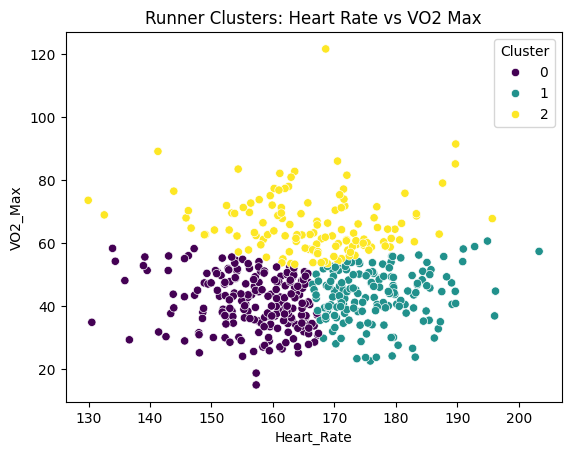

In [29]:

# --- SECTION 3: UNTERRICHTETEN ABHÄNGIGKEITEN (Multivariate/Structure) ---
print("\n--- 3. MULTIVARIATE & STRUCTURE ANALYSIS ---")

# A. PCA (Reducing dimensions of Heart Rate and VO2 Max)
pca = PCA(n_components=1)
df['Fitness_Index'] = pca.fit_transform(df[['Heart_Rate', 'VO2_Max']])
print(f"PCA: Explained Variance Ratio: {pca.explained_variance_ratio_[0]:.4f}")

# B. Cluster Analysis (Grouping runners based on stats)
kmeans = KMeans(n_clusters=3, n_init=10).fit(df[['Heart_Rate', 'VO2_Max']])
df['Cluster'] = kmeans.labels_
print(f"Cluster Analysis: Created {len(np.unique(kmeans.labels_))} groups of runners.")

# VISUALIZATION EXAMPLE
sns.scatterplot(data=df, x='Heart_Rate', y='VO2_Max', hue='Cluster', palette='viridis')
plt.title("Runner Clusters: Heart Rate vs VO2 Max")
plt.show()

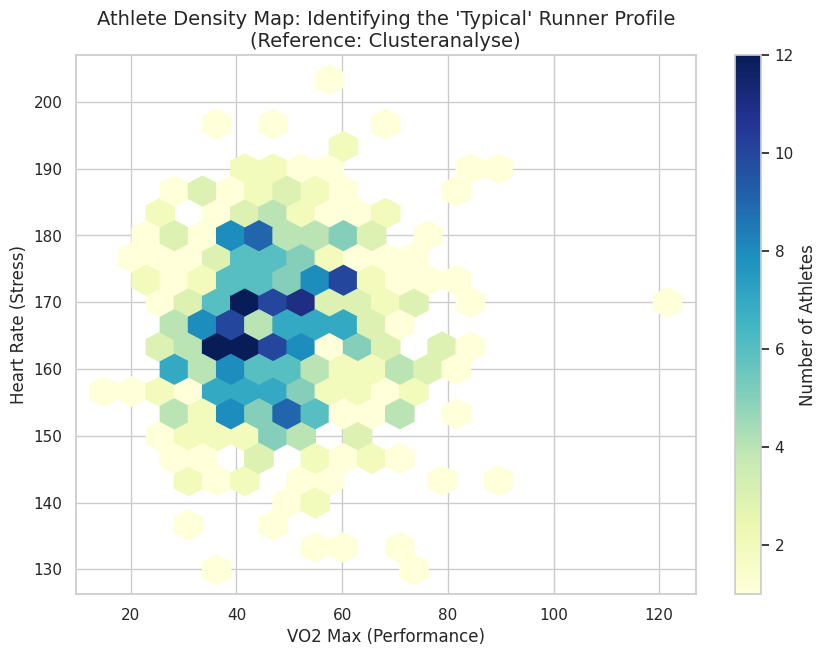

In [31]:
# --- E. HEXBIN PLOT: Intensity & Density ---
# This shows where the "bulk" of your athletes lie
plt.figure(figsize=(10, 7))
hb = plt.hexbin(df['VO2_Max'], df['Heart_Rate'], gridsize=20, cmap='YlGnBu', mincnt=1)
cb = plt.colorbar(hb, label='Number of Athletes')
plt.xlabel('VO2 Max (Performance)')
plt.ylabel('Heart Rate (Stress)')
plt.title("Athlete Density Map: Identifying the 'Typical' Runner Profile\n(Reference: Clusteranalyse)", fontsize=14)
plt.show()